## Data augmentation with Style Transfer model
Ansys로 생성한 가상 데이터의 형상이 실제 열화상 영상과 다른 양상을 가지므로 Defect detect transformer 모델의 학습 데이터로 사용하기 적합하지 않다고 판단됨.
따라서, ATD(Ansys Thermal data)가 가지는 Defect 부분의 특징이 손상되지 않는 선에서 적절한 Noise를 활용하여 FATD(FLIR Active Thermal Data)와 유사해보일 수 있도록 하는 전처리 과정을 고려함
전처리 과정은 다음과 같이 진행됨.

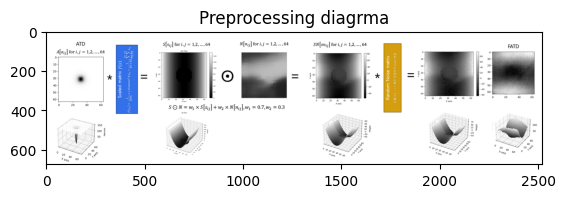

In [66]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
plt.subplot(1,1,1)
plt.title('Preprocessing diagrma')
plt.imshow(cv2.imread('preprocessing_diagram.png'))

In [77]:
target_image = cv2.imread('a.png', cv2.IMREAD_GRAYSCALE)
content_image = cv2.imread('b.png', cv2.IMREAD_GRAYSCALE)

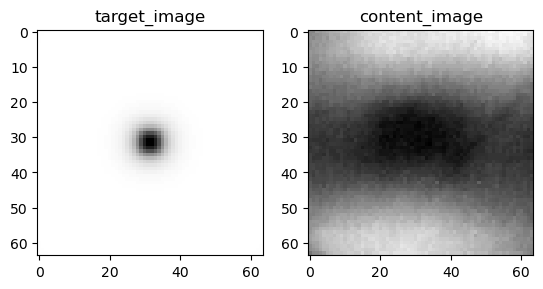

In [78]:
# 이미지 출력
plt.subplot(1, 2, 1)
plt.title('target_image')
plt.imshow(target_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('content_image')
plt.imshow(content_image, cmap='gray')

plt.show()
plt.close()

target max: 152
content max: 140
target min: 5
content min: 12
target mean: 149.63330078125
content mean: 71.09228515625
target mid: 152.0
content mid: 69.0


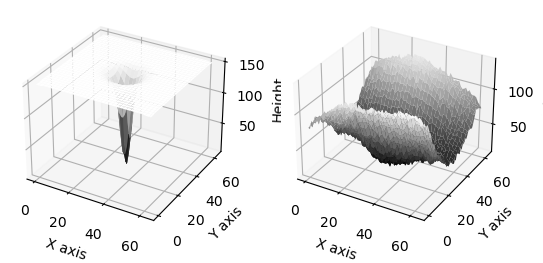

In [79]:
tdata = np.array(target_image)
cdata = np.array(content_image)

print('target max:', tdata.max())
print('content max:', cdata.max())

print('target min:', tdata.min())
print('content min:', cdata.min())

print('target mean:', np.mean(tdata))
print('content mean:', np.mean(cdata))

print('target mid:', np.median(tdata))
print('content mid:', np.median(cdata))

# X, Y 좌표 생성
tx = np.arange(tdata.shape[1])
ty = np.arange(tdata.shape[0])
tx, ty = np.meshgrid(tx, ty)

cx = np.arange(tdata.shape[1])
cy = np.arange(tdata.shape[0])
cx, cy = np.meshgrid(cx, cy)

# 3D 플롯 생성
fig = plt.figure()
ax = fig.add_subplot(121, projection='3d')
ay = fig.add_subplot(122, projection='3d')

# 표면 플롯
ax.plot_surface(tx, ty, tdata, cmap='gray')
ay.plot_surface(cx, cy, cdata, cmap='gray')


ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')
ax.set_zlabel('Height')

ay.set_xlabel('X axis')
ay.set_ylabel('Y axis')
ay.set_zlabel('Height')

plt.show()
plt.close()


max value: 152.0
min value: 0.0
mean value: 50.19799327850342
median value: 38.0


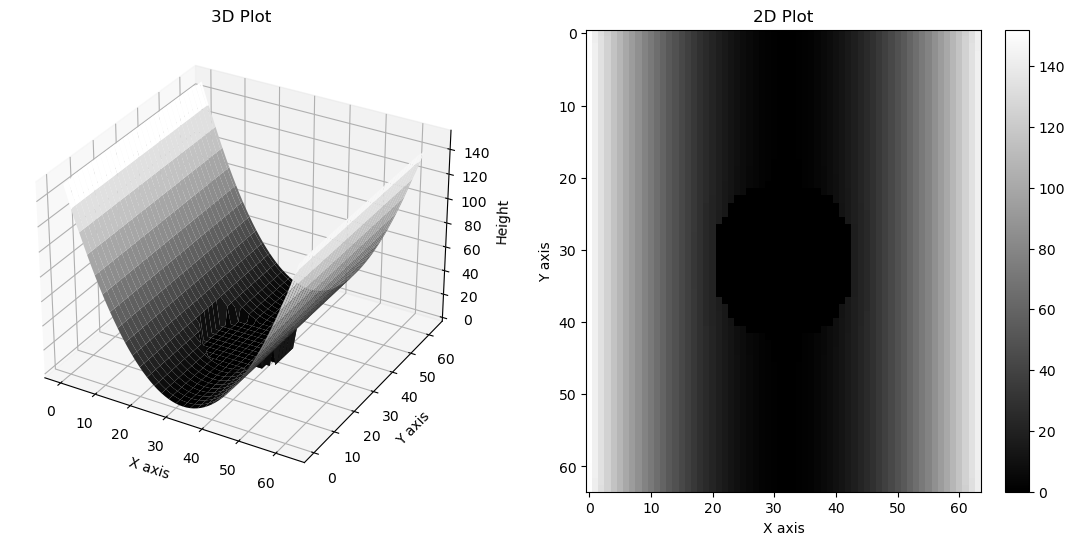

In [80]:
# X, Y 좌표 생성
x = np.arange(tdata.shape[1])
y = np.arange(tdata.shape[0])
x, y = np.meshgrid(x, y)

# 중심으로부터의 거리 계산
center_x = tdata.shape[1] // 2
center_y = tdata.shape[0] // 2

# 스케일 조정 비율 설정
scale_factors = np.zeros((tdata.shape[1],tdata.shape[1]))

# y축을 중심으로부터 멀어질수록 더 낮은 스케일 비율 적용
mean_tdata = np.mean(tdata)
for i in range(tdata.shape[0]):
    for j in range(tdata.shape[1]):
        if tdata[i, j] > mean_tdata:
            distance_y = (j - center_y)
            scale_factors[i, j] = (1 / 1024) * (distance_y ** 2)
            if scale_factors[i, j] < 0:
                scale_factors[i, j] = -scale_factors[i, j]
        
data_modified = tdata * scale_factors
max_value = data_modified.max()
min_value = data_modified.min()
mean_value = np.mean(data_modified)
mid_value = np.median(data_modified)
print('max value:', max_value)
print('min value:', min_value)
print('mean value:', mean_value)
print('median value:', mid_value)

# 3D 및 2D 플롯 생성
fig = plt.figure(figsize=(14, 6))

# 3D 플롯
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(x, y, data_modified, cmap='gray')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Height')
ax1.set_title('3D Plot')

# 2D 플롯
ax2 = fig.add_subplot(122)
cax = ax2.imshow(data_modified, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax2)
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
ax2.set_title('2D Plot')

plt.show()

#  Style Transfer Model
Using a style transfer model, generate noise that can make a preprocessed target image appear similar to a content image.
Easily apply style transfer using pre-trained models from TensorFlow Hub. (Based on Leon A. Gatys' paper "A Neural Algorithm of Artistic Style")

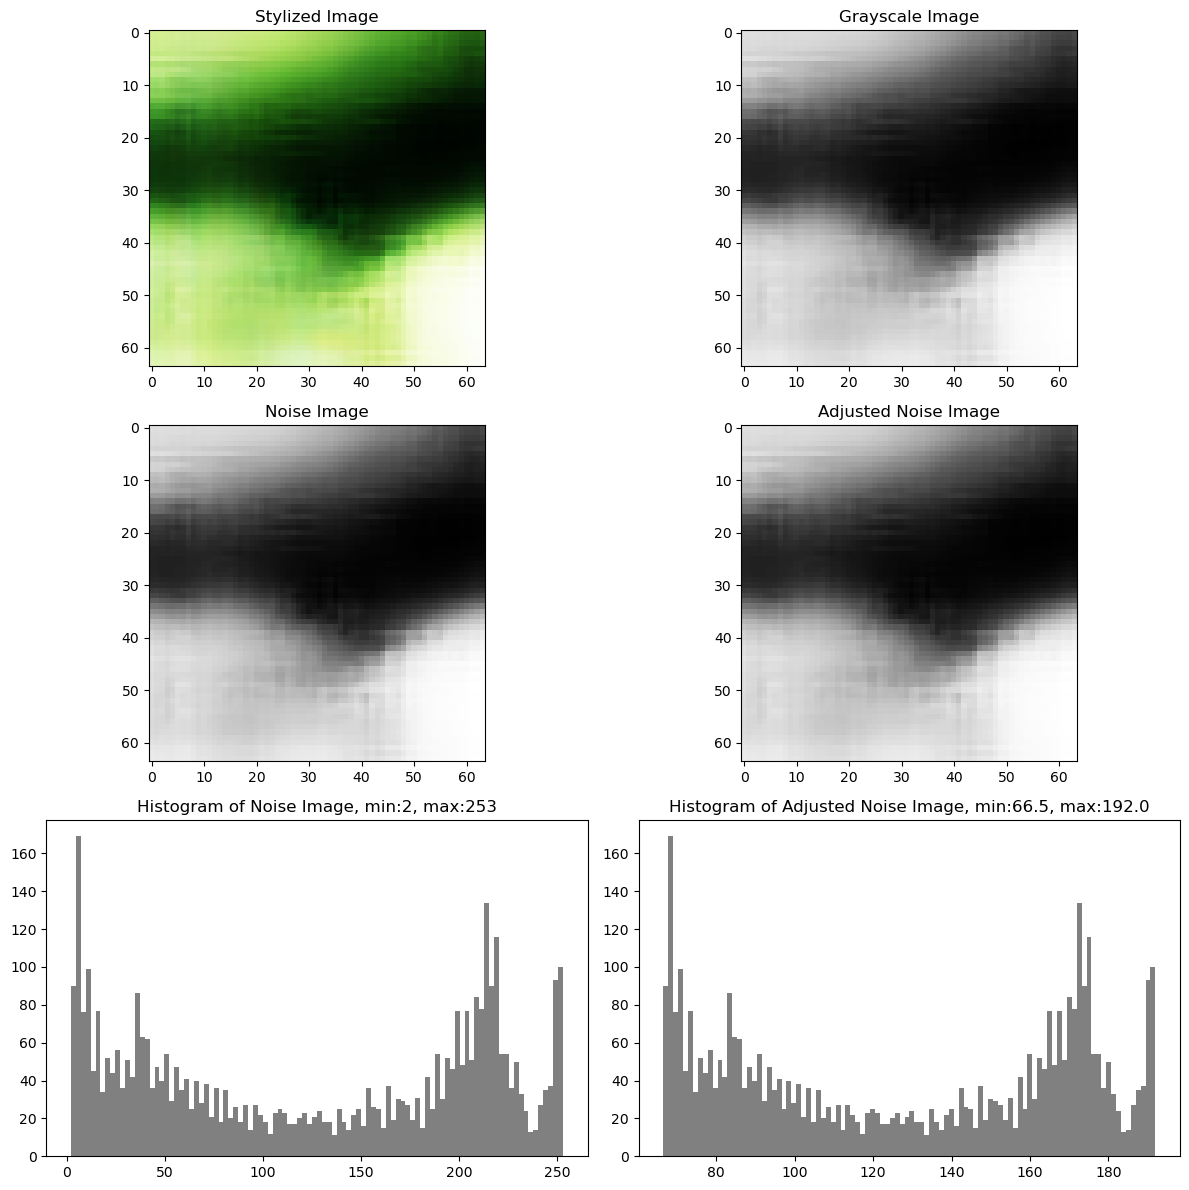

In [81]:
import numpy as np
import PIL.Image
import tensorflow as tf
import tensorflow_hub as hub
from IPython.display import display
import matplotlib.pyplot as plt

# 텐서를 이미지로 변환하는 함수
def tensor_to_image(tensor):
    tensor = tensor * 255
    tensor = np.array(tensor, dtype=np.uint8)
    if np.ndim(tensor) > 3:
        assert tensor.shape[0] == 1
        tensor = tensor[0]
    return PIL.Image.fromarray(tensor)

# 이미지를 로드하는 함수
def load_img(path_to_img):
    max_dim = 64
    img = tf.io.read_file(path_to_img)
    img = tf.image.decode_image(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)

    shape = tf.cast(tf.shape(img)[:-1], tf.float32)
    long_dim = max(shape)
    scale = max_dim / long_dim

    new_shape = tf.cast(shape * scale, tf.int32)

    img = tf.image.resize(img, new_shape)
    img = img[tf.newaxis, :]
    return img

# 이미지 로드
target_image = load_img('a.png')
content_image = load_img('b.png')

# 스타일 변환 모델 로드 및 적용
hub_model = hub.load('https://tfhub.dev/google/magenta/arbitrary-image-stylization-v1-256/2')
stylized_image = hub_model(tf.constant(target_image), tf.constant(content_image))[0]

# 텐서를 이미지로 변환
stylized_pil_image = tensor_to_image(stylized_image)

# 텐서 이미지를 그레이스케일로 변환
noise_image = stylized_pil_image.convert('L')

# 최소값과 최대값 설정
min_val = np.min(noise_image)
max_val = np.max(noise_image)

# 이미지를 numpy 배열로 변환
noise_array = np.array(noise_image)
ori_noise_array = np.copy(noise_array)

# 최소값과 최대값 제한 적용
original_noise_array = np.clip(noise_array, min_val, max_val)


# 편차 줄이기 함수
def reduce_deviation(array, factor=0.5):
    median = np.median(array)  # 배열의 중앙값을 계산
    adjusted_array = median + factor * (array - median)  # 편차 줄이기
    return adjusted_array

# adjusted_noise_array 복사 후 편차 줄이기 함수 적용
adjusted_noise_array = np.copy(noise_array)
adjusted_noise_array = reduce_deviation(adjusted_noise_array, factor=0.5)  # factor 값을 더 크게 설정

# 결과 이미지 표시 및 히스토그램
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

# 원본 스타일 이미지
axs[0, 0].set_title('Stylized Image')
axs[0, 0].imshow(stylized_pil_image)

# 그레이스케일 이미지
axs[0, 1].set_title('Grayscale Image')
axs[0, 1].imshow(ori_noise_array, cmap='gray')

# 원본 노이즈 이미지
axs[1, 0].set_title('Noise Image')
axs[1, 0].imshow(original_noise_array, cmap='gray')

# 조정된 노이즈 이미지
axs[1, 1].set_title('Adjusted Noise Image')
axs[1, 1].imshow(adjusted_noise_array, cmap='gray')

# 원본 노이즈 이미지 히스토그램
axs[2, 0].set_title(f'Histogram of Noise Image, min:{original_noise_array.min()}, max:{original_noise_array.max()}')
original_noise_array_hist = original_noise_array.flatten()
axs[2, 0].hist(original_noise_array_hist, bins=100, color='gray')

# 조정된 노이즈 이미지 히스토그램
axs[2, 1].set_title(f'Histogram of Adjusted Noise Image, min:{adjusted_noise_array.min()}, max:{adjusted_noise_array.max()}')
adjusted_noise_array_hist = adjusted_noise_array.flatten()
axs[2, 1].hist(adjusted_noise_array_hist, bins=100, color='gray')

plt.tight_layout()
plt.show()


생성한 adjusted noise image와 modified data를 합성
- 동일한 크기의 두 행렬을 합성
- CASE1 : adjusted_noise_array[i,j] * factor + data_modified[i,j] = data_modified[i,j]
- CASE2 : (adjusted_noise_array[i,j] + data_modified[i,j])/2 = data_modified[i,j]
- CASE3 : (weight1 * adjusted_noise_array[i,j]) + (weight2 * data_modified[i,j]) = data_modified[i,j]

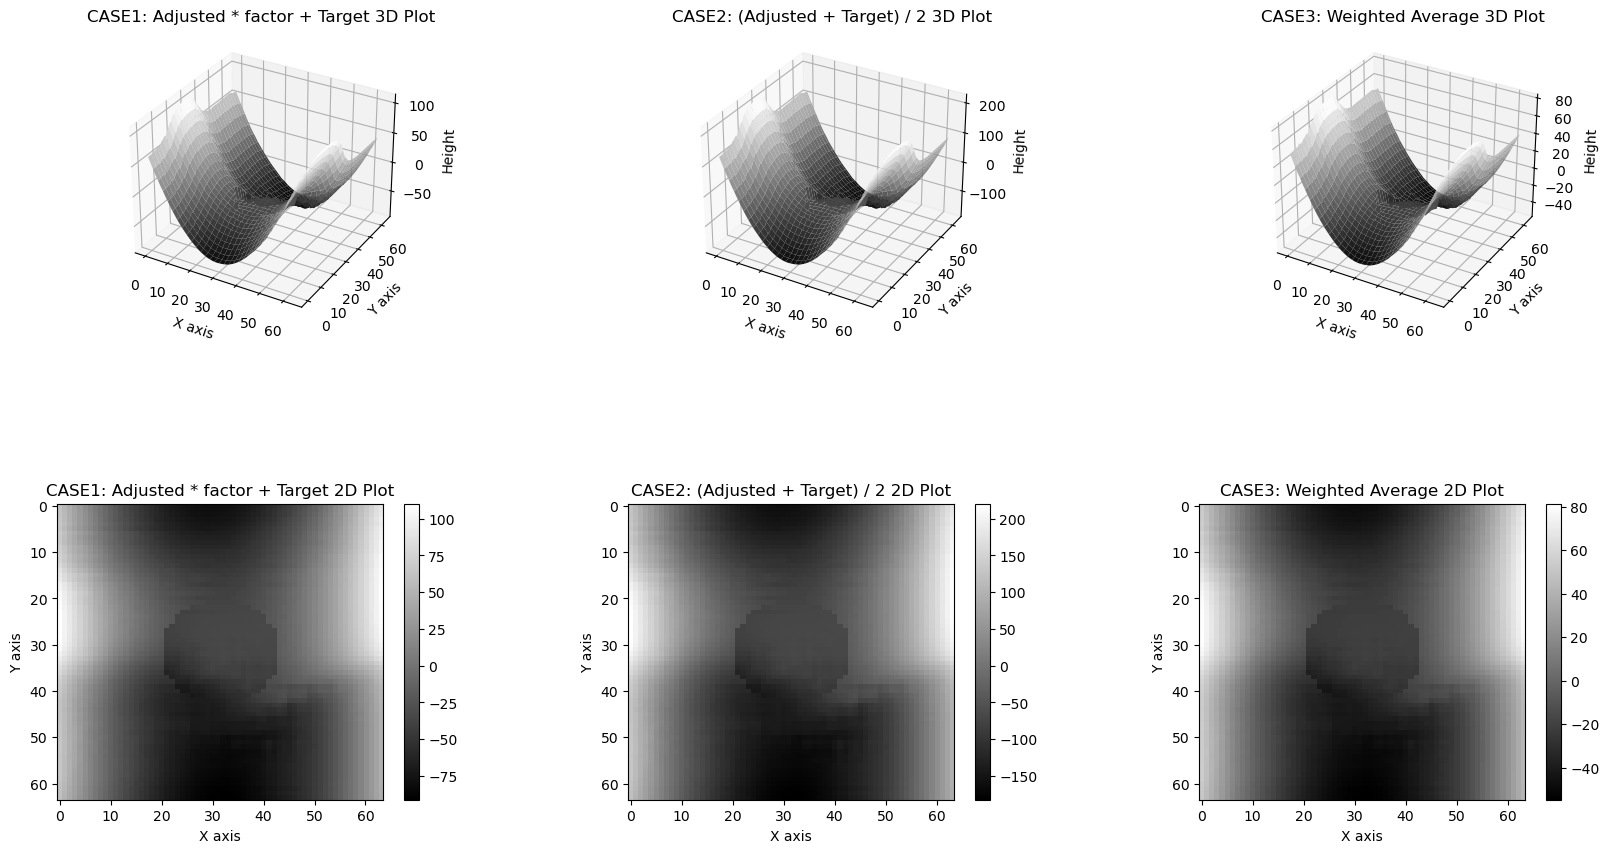

In [95]:
# CASE1: adjusted_noise_array[i, j] * factor + target_array[i, j] = target_array[i, j]
factor = 0.5
case1_array = data_modified - factor * adjusted_noise_array

# CASE2: (adjusted_noise_array[i, j] + target_array[i, j]) / 2 = target_array[i, j]
case2_array = 2 * data_modified - adjusted_noise_array

# CASE3: (weight1 * adjusted_noise_array[i, j]) + (weight2 * target_array[i, j]) = target_array[i, j]
weight1 = 0.7
weight2 = 0.3
# y축을 중심으로부터 멀어질수록 더 낮은 스케일 비율 적용
case3_array = (weight1 * data_modified - weight2 * adjusted_noise_array)


# CASE1 결과
axs[1, 0].set_title('CASE1: Adjusted * factor + Target')
axs[1, 0].imshow(case1_array, cmap='gray')

# CASE2 결과
axs[1, 1].set_title('CASE2: (Adjusted + Target) / 2')
axs[1, 1].imshow(case2_array, cmap='gray')

# CASE3 결과
axs[2, 0].set_title('CASE3: Weighted Average')
axs[2, 0].imshow(case3_array, cmap='gray')


# 3D 및 2D 플롯 생성
fig = plt.figure(figsize=(20, 10))

##### CASE1 3D 플롯 & 2D 플롯
# X, Y 좌표 생성
x1 = np.arange(case1_array.shape[1])
y1 = np.arange(case1_array.shape[0])
x1, y1 = np.meshgrid(x1, y1)

ax1 = fig.add_subplot(231, projection='3d')
ax1.plot_surface(x1, y1, case1_array, cmap='gray')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Height')
ax1.set_title('CASE1: Adjusted * factor + Target 3D Plot')

ax2 = fig.add_subplot(234)
cax = ax2.imshow(case1_array, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax2)
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
ax2.set_title('CASE1: Adjusted * factor + Target 2D Plot')

##### CASE2 3D 플롯 & 2D 플롯
# X, Y 좌표 생성
x2 = np.arange(case2_array.shape[1])
y2 = np.arange(case2_array.shape[0])
x2, y2 = np.meshgrid(x2, y2)

ax3 = fig.add_subplot(232, projection='3d')
ax3.plot_surface(x2, y2, case2_array, cmap='gray')
ax3.set_xlabel('X axis')
ax3.set_ylabel('Y axis')
ax3.set_zlabel('Height')
ax3.set_title('CASE2: (Adjusted + Target) / 2 3D Plot')

ax4 = fig.add_subplot(235)
cax = ax4.imshow(case2_array, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax4)
ax4.set_xlabel('X axis')
ax4.set_ylabel('Y axis')
ax4.set_title('CASE2: (Adjusted + Target) / 2 2D Plot')

##### CASE3 3D 플롯 & 2D 플롯
# X, Y 좌표 생성
x3 = np.arange(case3_array.shape[1])
y3 = np.arange(case3_array.shape[0])
x3, y3 = np.meshgrid(x3, y3)

ax5 = fig.add_subplot(233, projection='3d')
ax5.plot_surface(x3, y3, case3_array, cmap='gray')
ax5.set_xlabel('X axis')
ax5.set_ylabel('Y axis')
ax5.set_zlabel('Height')
ax5.set_title('CASE3: Weighted Average 3D Plot')

ax6 = fig.add_subplot(236)
cax = ax6.imshow(case3_array, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax6)
ax6.set_xlabel('X axis')
ax6.set_ylabel('Y axis')
ax6.set_title('CASE3: Weighted Average 2D Plot')

plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()

각 CASE 연산 결과로 나온 array에 정규분포 random noise 추가

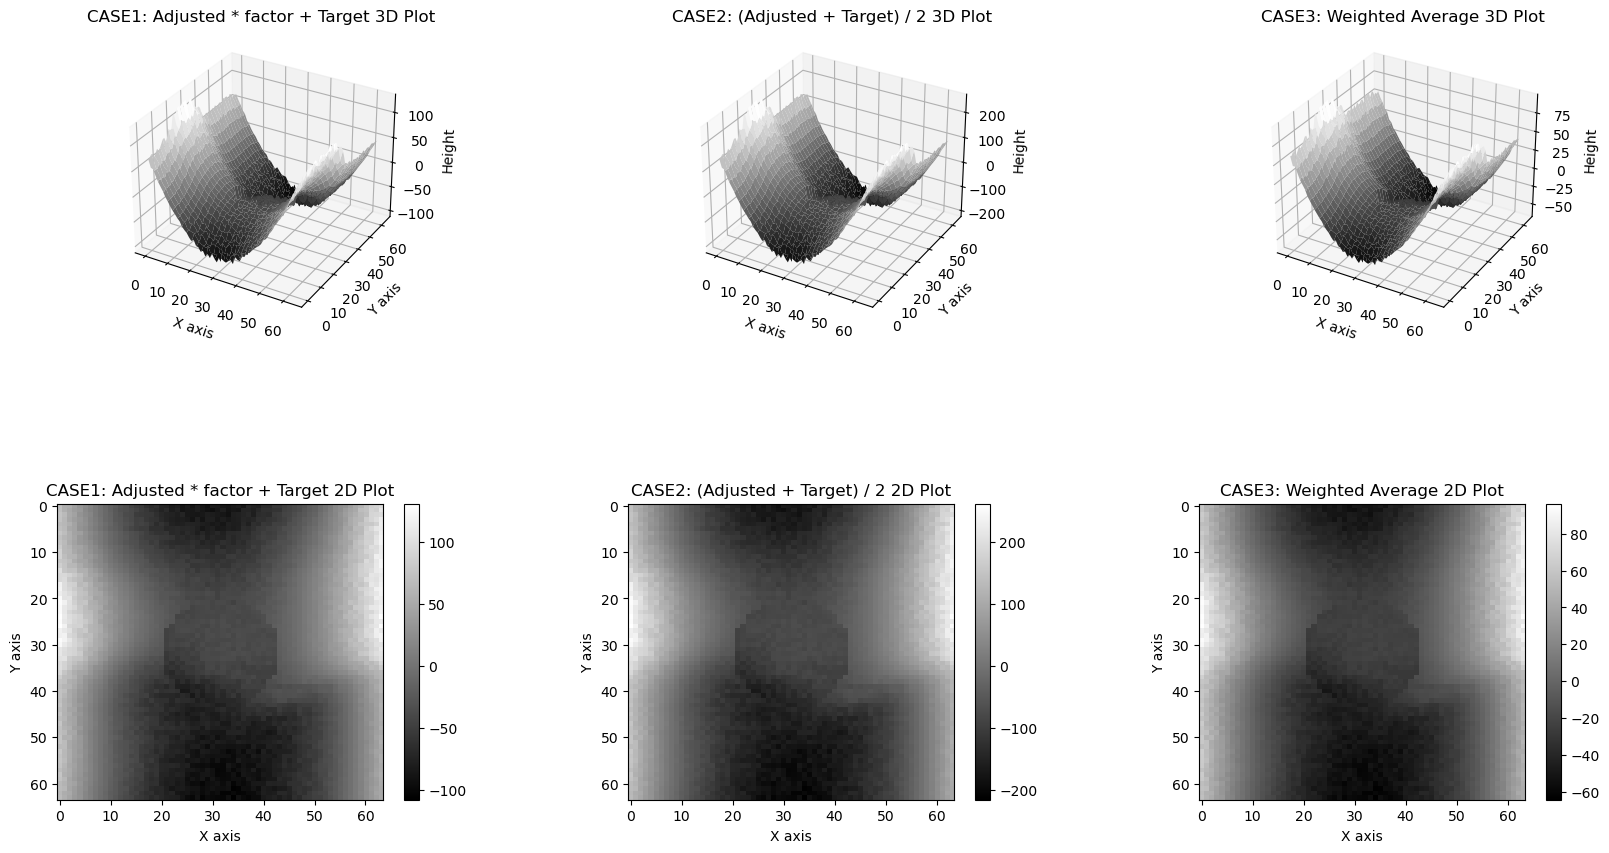

In [99]:
random_factors = np.random.uniform(1, 1.2, (case1_array.shape[0], case1_array.shape[1]))

# CASE1: adjusted_noise_array[i, j] * factor + target_array[i, j] = target_array[i, j]
factor = 0.5
case1_array = data_modified - factor * adjusted_noise_array
case1_array = case1_array * random_factors

# CASE2: (adjusted_noise_array[i, j] + target_array[i, j]) / 2 = target_array[i, j]
case2_array = 2 * data_modified - adjusted_noise_array
case2_array = case2_array * random_factors

# CASE3: (weight1 * adjusted_noise_array[i, j]) + (weight2 * target_array[i, j]) = target_array[i, j]
weight1 = 0.7
weight2 = 0.3
# y축을 중심으로부터 멀어질수록 더 낮은 스케일 비율 적용
case3_array = (weight1 * data_modified - weight2 * adjusted_noise_array)
case3_array = case3_array * random_factors

# CASE1 결과
axs[1, 0].set_title('CASE1: Adjusted * factor + Target')
axs[1, 0].imshow(case1_array, cmap='gray')

# CASE2 결과
axs[1, 1].set_title('CASE2: (Adjusted + Target) / 2')
axs[1, 1].imshow(case2_array, cmap='gray')

# CASE3 결과
axs[2, 0].set_title('CASE3: Weighted Average')
axs[2, 0].imshow(case3_array, cmap='gray')


# 3D 및 2D 플롯 생성
fig = plt.figure(figsize=(20, 10))

##### CASE1 3D 플롯 & 2D 플롯
# X, Y 좌표 생성
x1 = np.arange(case1_array.shape[1])
y1 = np.arange(case1_array.shape[0])
x1, y1 = np.meshgrid(x1, y1)

ax1 = fig.add_subplot(231, projection='3d')
ax1.plot_surface(x1, y1, case1_array, cmap='gray')
ax1.set_xlabel('X axis')
ax1.set_ylabel('Y axis')
ax1.set_zlabel('Height')
ax1.set_title('CASE1: Adjusted * factor + Target 3D Plot')

ax2 = fig.add_subplot(234)
cax = ax2.imshow(case1_array, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax2)
ax2.set_xlabel('X axis')
ax2.set_ylabel('Y axis')
ax2.set_title('CASE1: Adjusted * factor + Target 2D Plot')

##### CASE2 3D 플롯 & 2D 플롯
# X, Y 좌표 생성
x2 = np.arange(case2_array.shape[1])
y2 = np.arange(case2_array.shape[0])
x2, y2 = np.meshgrid(x2, y2)

ax3 = fig.add_subplot(232, projection='3d')
ax3.plot_surface(x2, y2, case2_array, cmap='gray')
ax3.set_xlabel('X axis')
ax3.set_ylabel('Y axis')
ax3.set_zlabel('Height')
ax3.set_title('CASE2: (Adjusted + Target) / 2 3D Plot')

ax4 = fig.add_subplot(235)
cax = ax4.imshow(case2_array, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax4)
ax4.set_xlabel('X axis')
ax4.set_ylabel('Y axis')
ax4.set_title('CASE2: (Adjusted + Target) / 2 2D Plot')

##### CASE3 3D 플롯 & 2D 플롯
# X, Y 좌표 생성
x3 = np.arange(case3_array.shape[1])
y3 = np.arange(case3_array.shape[0])
x3, y3 = np.meshgrid(x3, y3)

ax5 = fig.add_subplot(233, projection='3d')
ax5.plot_surface(x3, y3, case3_array, cmap='gray')
ax5.set_xlabel('X axis')
ax5.set_ylabel('Y axis')
ax5.set_zlabel('Height')
ax5.set_title('CASE3: Weighted Average 3D Plot')

ax6 = fig.add_subplot(236)
cax = ax6.imshow(case3_array, cmap='gray', aspect='auto')
fig.colorbar(cax, ax=ax6)
ax6.set_xlabel('X axis')
ax6.set_ylabel('Y axis')
ax6.set_title('CASE3: Weighted Average 2D Plot')

plt.subplots_adjust(wspace=0.4, hspace=0.6)
plt.show()